<a href="https://colab.research.google.com/github/funxyz2/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

2.8.0+cu126


## 1. What are 3 areas in industry where computer vision is currently being used?

* **Healthcare and Medical Imaging**
* **Manufacturing and Quality Control**
* **Transportation and Automotive**


## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

In machine learning, overfitting occurs when a model fits the training data too closely—capturing noise and irrelevant patterns—so it performs poorly on new, unseen data



## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

Regularization:

- l1, là giảm toàn bộ với đều 1 khoảng cách, trọng số nhỏ đến lúc sẽ đạt mốc 0 và ko thể giảm nữa

- l2 thì do dùng bình nên các trọng số nhỏ thì ko bị ảnh hưởng nhiều, chỉ có trọng số lớn mới bị phạt nặng

- elastic net là cân bằng, cộng loss cho l1 + l2

- Dropout, bỏ bớt neuron ngẫu nhiên mỗi epoch, các neuron khác phải tự thân học pattern, ko nhờ vào 1 neuron cụ thể

Early Stopping:

Cross-validation:

Thay vì train trên 1 phần dữ liệu và test trên phần còn lại, cross-validation sẽ:

1. Chia dữ liệu thành nhiều phần nhỏ (folds).

2. Lặp lại quá trình train-test nhiều lần, mỗi lần dùng một fold làm test set, các fold còn lại làm train set.

3. Trung bình kết quả từ các lần test → đánh giá đáng tin cậy hơn.

**K-Fold Cross Validation**

Chia dữ liệu thành k phần bằng nhau.

Lặp k lần: mỗi lần chọn 1 fold để test, còn lại để train.

Kết quả cuối = trung bình của k lần.
👉 Thường dùng k = 5 hoặc k = 10.

**Stratified K-Fold**

Giống K-Fold nhưng giữ nguyên tỷ lệ các class trong mỗi fold (dùng cho classification mất cân bằng dữ liệu).

**Leave-One-Out Cross Validation (LOOCV)**

Mỗi lần chỉ bỏ 1 mẫu để test, train trên tất cả các mẫu còn lại.

Lặp lại cho toàn bộ dataset.

Rất chính xác nhưng tốn nhiều chi phí tính toán.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [3]:
import torch, torchvision
from torchvision.datasets import MNIST
from torchvision import transforms
# train
train_data = MNIST(root='/content/', train=True, download=True, transform=transforms.ToTensor())
# Test
test_data = MNIST(root='/content/', train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 54.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.68MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.17MB/s]


In [4]:
len(train_data), len(test_data)

(60000, 10000)

In [5]:
image, label = train_data[0]
print(image.shape)
print(label)

torch.Size([1, 28, 28])
5


## 6. Visualize at least 5 different samples of the MNIST training dataset.

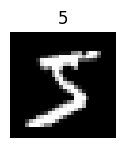

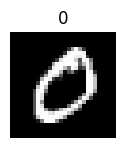

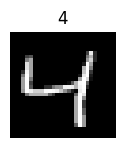

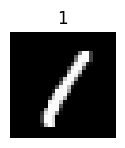

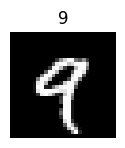

In [6]:
import matplotlib.pyplot as plt

for i in range(5):
  image = train_data[i][0].squeeze()
  label = train_data[i][1]

  plt.figure(figsize=(3,3))
  plt.subplot(1, 2, 2)
  plt.imshow(image, cmap='gray')
  plt.title(label)
  plt.axis(False)
  plt.show()

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [7]:
from torch.utils.data import DataLoader

# train
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
# test
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [8]:
train_loader, test_loader

(<torch.utils.data.dataloader.DataLoader at 0x7a997d2fbb00>,
 <torch.utils.data.dataloader.DataLoader at 0x7a997d830b00>)

In [9]:
img, label = next(iter(train_loader))
img.shape, label.shape

for sample in next(iter(train_loader)):
  print(sample.shape)

torch.Size([32, 1, 28, 28])
torch.Size([32])


## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [10]:
from torch import nn

class TiNyVGG(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()

    # First Convo block
    self.conv_block1 = nn.Sequential(
        nn.Conv2d(input_shape, hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    # Second Convo block
    self.conv_block2= nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, 3, 1, 1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, 3, 1, 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    # Classifier block
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(hidden_units*7*7, output_shape)
    )

  def forward(self, x):
    x = self.conv_block1(x)
    x = self.conv_block2(x)
    x = self.classifier(x)
    return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TiNyVGG(1, 10, 10).to(device)
model

TiNyVGG(
  (conv_block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [11]:
# dummy forward to ensure shape we want
dummy = torch.rand(1, 28, 28).unsqueeze(dim=0).to(device) # giả mạo chiều batch, vì cnn yêu cầu (batch, C, H, W)
dummy.shape


torch.Size([1, 1, 28, 28])

In [12]:
model(dummy)

tensor([[ 0.0377, -0.0457,  0.0127,  0.0371,  0.0160,  0.0551,  0.0444,  0.0240,
         -0.0042, -0.0156]], grad_fn=<AddmmBackward0>)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [17]:
from tqdm.auto import tqdm

model_cpu = TiNyVGG(1, 10, 10).to('cpu')

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_cpu.parameters(), lr=0.1)

epochs = 5
for epoch in tqdm(range(epochs)):
  train_loss = 0
  for batch, (X, y) in enumerate(train_loader):
    model_cpu.train()

    X,y = X.to('cpu'), y.to('cpu')

    y_pred = model_cpu(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(train_loader)

  # Eval
  test_loss_total = 0
  model_cpu.eval()

  with torch.inference_mode():
    for batch, (X_test, y_test) in enumerate(test_loader):
      X_test, y_test = X_test.to(device), y_test.to(device)

      test_pred = model_cpu(X_test)
      test_loss = loss_fn(test_pred, y_test)

      test_loss_total += test_loss

    test_loss_total /= len(test_loader)

  print(f"Epoch: {epoch} | Loss: {train_loss}, | Test Loss: {test_loss_total}")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Loss: 0.3604612350463867, | Test Loss: 0.13201624155044556
Epoch: 1 | Loss: 0.08008835464715958, | Test Loss: 0.05770806968212128
Epoch: 2 | Loss: 0.062370236963033676, | Test Loss: 0.05876367911696434
Epoch: 3 | Loss: 0.05370823293924332, | Test Loss: 0.046917032450437546
Epoch: 4 | Loss: 0.046082504093647, | Test Loss: 0.04241161420941353


In [25]:
device

'cpu'

In [27]:
%%time
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

model_gpu = TiNyVGG(1, 10, 10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_gpu.parameters(), lr=0.1)

epochs = 5
for epoch in tqdm(range(epochs)):
  train_loss_total = 0
  model_gpu.train()
  for batch, (X_train, y_train) in enumerate(train_loader):
    X_train, y_train = X_train.to(device), y_train.to(device)

    y_pred = model_gpu(X_train)
    loss = loss_fn(y_pred, y_train)
    train_loss_total += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss_total /= len(train_loader)

  test_loss_total = 0
  model_gpu.eval()
  with torch.inference_mode():
    for batch, (X_test, y_test) in enumerate(test_loader):
      X_test, y_test = X_test.to(device), y_test.to(device)

      test_pred = model_gpu(X_test)
      test_loss = loss_fn(test_pred, y_test)

      test_loss_total += test_loss.item()

  test_loss_total /= len(test_loader)

  print(f'Epoch: {epoch} | Loss: {train_loss_total} | Test loss: {test_loss_total}')


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Loss: 0.33620520766545087 | Test loss: 0.08039655684256933
Epoch: 1 | Loss: 0.07485581181651602 | Test loss: 0.0528940021438571
Epoch: 2 | Loss: 0.05636223754021339 | Test loss: 0.06503548944081082
Epoch: 3 | Loss: 0.047929567550867795 | Test loss: 0.04262940853798539
Epoch: 4 | Loss: 0.04161319952782942 | Test loss: 0.04078948132492121
CPU times: user 4min 20s, sys: 214 ms, total: 4min 20s
Wall time: 4min 22s


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?